In [ ]:
import pandas as pd

fpath = '/kaggle/input/vertebrate/vertebrate.csv'
# data = pd.read_csv('vertebrate.csv',header='infer')
data = pd.read_csv(fpath)
data

In [ ]:
data['Class'] = data['Class'].replace(['fishes','birds','amphibians','reptiles'],'non-mammals')
data

In [ ]:
from sklearn import tree
import matplotlib.pyplot as plt

Y = data['Class']
X = data.drop(['Name', 'Class'],axis=1)

clf = tree.DecisionTreeClassifier(criterion='entropy',max_depth=3)
clf = clf.fit(X, Y)

In [ ]:
plt.figure(figsize=(10, 10))
tree.plot_tree(clf, feature_names=['Warm-blooded', 'Gives Birth', 
'Aquatic Creature','Aerial Creature', 'Has Legs', 'Hibernates'], class_names=['mammals', 'non-mammals'], filled=True, rounded=True, fontsize=12)
plt.show()

In [ ]:
from sklearn.tree import export_text

tree_rules = export_text(clf, feature_names=['Warm-blooded', 'Gives Birth', 
'Aquatic Creature','Aerial Creature', 'Has Legs', 'Hibernates'])

print(tree_rules)

In [ ]:
#split the dataset
from sklearn.model_selection import train_test_split
X_train, test_x, y_train, test_lab = train_test_split(X,Y,
                                                 test_size = 0.4,
                                                 random_state = 42)
      
clf = clf.fit(X_train, y_train)  ## REMEMBER!!!! Never test on train data            
test_pred_decision_tree = clf.predict(test_x)

In [ ]:
#import the relevant packages
from sklearn import metrics
import seaborn as sns
import matplotlib.pyplot as plt
#get the confusion matrix
confusion_matrix = metrics.confusion_matrix(test_lab,  
                                            test_pred_decision_tree)
#turn this into a dataframe
matrix_df = pd.DataFrame(confusion_matrix)
#plot the result
ax = plt.axes()
sns.set(font_scale=1.3)
plt.figure(figsize=(15,10))
sns.heatmap(matrix_df, annot=True, fmt="g", ax=ax, cmap="magma")
#set axis titles
ax.set_title('Confusion Matrix - Decision Tree')
ax.set_xlabel("Predicted label", fontsize =15)
ax.set_xticklabels(['mammals', 'non-mammals'])
ax.set_ylabel("True Label", fontsize=15)
ax.set_yticklabels(['mammals', 'non-mammals'], rotation = 0)
plt.show()

In [ ]:
print(metrics.classification_report(test_lab,
                                    test_pred_decision_tree))

# 3. Model Overfitting
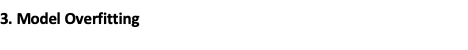
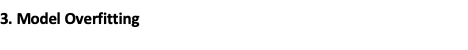
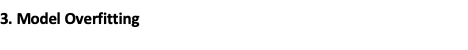
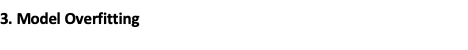

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import random

%matplotlib inline

N = 1500

mean1 = [6, 14]
mean2 = [10, 6]
mean3 = [14, 14]
cov = [[3.5, 0], [0, 3.5]]  # diagonal covariance

np.random.seed(50)
X = np.random.multivariate_normal(mean1, cov, int(N/6))
X = np.concatenate((X, np.random.multivariate_normal(mean2, cov, int(N/6))))
X = np.concatenate((X, np.random.multivariate_normal(mean3, cov, int(N/6))))
X = np.concatenate((X, 20*np.random.rand(int(N/2),2)))
Y = np.concatenate((np.ones(int(N/2)),np.zeros(int(N/2))))
plt.figure(figsize=(10,10))
plt.plot(X[:int(N/2),0],X[:int(N/2),1],'r+',X[int(N/2):,0],X[int(N/2):,1],'k.',ms=4)

In [ ]:
#########################################
# Training and Test set creation
#########################################

from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=1)

from sklearn import tree
from sklearn.metrics import accuracy_score

#########################################
# Model fitting and evaluation
#########################################

maxdepths = [2,3,4,5,6,7,8,9,10,15,20,25,30,35,40,45,50]

trainAcc = np.zeros(len(maxdepths))
testAcc = np.zeros(len(maxdepths))

index = 0
for depth in maxdepths:
    clf = tree.DecisionTreeClassifier(max_depth=depth)
    clf = clf.fit(X_train, Y_train)
    Y_predTrain = clf.predict(X_train)
    Y_predTest = clf.predict(X_test)
    trainAcc[index] = accuracy_score(Y_train, Y_predTrain)
    testAcc[index] = accuracy_score(Y_test, Y_predTest)
    index += 1
    
#########################################
# Plot of training and test accuracies
#########################################
    
plt.plot(maxdepths,trainAcc,'ro-',maxdepths,testAcc,'bv--')
plt.legend(['Training Accuracy','Test Accuracy'])
plt.xlabel('Max depth')
plt.ylabel('Accuracy')